# Used Car Price Prediction

## Project Description
We are using the pre-processed data from a previous case study on predicting old car prices. You can check the data cleansing and feature selection steps from this link:<br>
https://thinkingneuron.com/car-price-prediction-case-study-in-python/.

## Importing the Libraries

In [1]:
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt

### Importing the Dataset

<font color='red'> Note:<br>
<font color='black'> The type of data is "pickle", which is very similar to csv; and after uploading it into the code; we treat the file same as csv files.


In [2]:
dataset = pd.read_pickle('CarPricesData.pkl')

In [3]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1435 entries, 0 to 1435
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Age       1435 non-null   float64
 1   KM        1435 non-null   int64  
 2   Weight    1435 non-null   float64
 3   HP        1435 non-null   int64  
 4   MetColor  1435 non-null   int64  
 5   CC        1435 non-null   float64
 6   Doors     1435 non-null   int64  
 7   Price     1435 non-null   int64  
dtypes: float64(3), int64(5)
memory usage: 100.9 KB


Price: The Price of the car in dollars
Age: The age of the car in months
KM: How many KMS did the car was used
HP: Horsepower of the car
MetColor: Whether the car has a metallic color or not
CC: The engine size of the car
Doors: The number of doors in the car
Weight: The weight of the car

In [4]:
dataset.describe()

,Age,KM,Weight,HP,MetColor,CC,Doors,Price
count,1435.000000,1435.000000,1435.000000,1435.000000,1435.000000,1435.000000,1435.000000,1435.000000
mean,56.027178,68571.782578,1071.659930,101.491986,0.674564,1566.735192,4.032753,10720.915679
std,18.532943,37491.094553,47.688509,14.981408,0.468701,186.767122,0.952667,3608.732978
min,1.000000,1.000000,1000.000000,69.000000,0.000000,1300.000000,2.000000,4350.000000
25%,44.000000,43000.000000,1040.000000,90.000000,0.000000,1400.000000,3.000000,8450.000000
50%,61.000000,63451.000000,1070.000000,110.000000,1.000000,1600.000000,4.000000,9900.000000
75%,70.000000,87041.500000,1085.000000,110.000000,1.000000,1600.000000,5.000000,11950.000000
max,80.000000,243000.000000,1320.000000,192.000000,1.000000,2000.000000,5.000000,32500.000000


In [5]:
dataset.head(5)

,Age,KM,Weight,HP,MetColor,CC,Doors,Price
0,23.0,46986,1165.0,90,1,2000.0,3,13500
1,23.0,72937,1165.0,90,1,2000.0,3,13750
2,24.0,41711,1165.0,90,1,2000.0,3,13950
3,26.0,48000,1165.0,90,0,2000.0,3,14950
4,30.0,38500,1170.0,90,0,2000.0,3,13750


### Seperate the input and output

In [6]:
X = dataset.iloc[:, :-1].values
y = dataset.iloc[:, -1].values

### Splitting the Dataset into the Training set and Test set

In [7]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 1)

In [8]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(1148, 7)
(287, 7)
(1148,)
(287,)


### Feature Scaling

In [9]:
from sklearn.preprocessing import StandardScaler

scx = StandardScaler()
scy = StandardScaler()

X_train = scx.fit_transform(X_train)
X_test = scx.transform(X_test)

y_train = scy.fit_transform((y_train).reshape(-1,1))
y_test = scy.transform((y_test).reshape(-1,1))

## Building the ANN Regressor

### Initializing the ANN

In [10]:
CarPrice_1 = tf.keras.models.Sequential()
CarPrice_2 = tf.keras.models.Sequential()
CarPrice_3 = tf.keras.models.Sequential()

This initializes an empty sequential model called CarPrice_i, which doesn't have any layers yet.

**Sequential():** In a Sequential model, you can arrange the layers of the neural network in a sequential order, one after the other.

**Model=tf.keras.models.Sequential()** is creating a new neural network model using the Sequential model. This model will allow us to stack layers one after another. In simpler terms, think of it as setting up a framework or a blank canvas where we can start building our neural network by adding layers one by one in a specific order.

### Adding the Input Layer

In [11]:
CarPrice_1.add(tf.keras.layers.Dense(units=7, activation='relu')) # One Large hidden layer: 7/200/1
CarPrice_2.add(tf.keras.layers.Dense(units=7, activation='relu')) # 1 hidden Layers: 7/10/1
CarPrice_3.add(tf.keras.layers.Dense(units=7, activation='relu')) # 4 hidden Layers: 7/28/21/14/7/1

**layers:** a tool to access the different types of layers.

**Dense:** The Dense layer is a standard layer in a neural network where every neuron (or "node") in the layer is connected to every neuron in the previous and following layers.

**units=7:** This layer will have 7 nodes, each handling a different aspect of our data.

**activation='relu':** The activation function helps the neuron decide if it should respond strongly or not based on its input. In this case, we're using 'relu' (which stands for Rectified Linear Unit), a common and effective activation function.

### Adding the First, Second, Third,... Hidden layers

#### CarPrice_1: one large hidden layer with 200 nodes

In [12]:
CarPrice_1.add(tf.keras.layers.Dense(units=200, activation='relu'))

You're effectively building a network where each layer learns to represent the data in a more sophisticated way, using multiple neurons to extract different aspects or features from the input.
    

**Deciding the number of neurons in the hidden layers:**
1. If you have a small dataset, having a smaller number of neurons can help prevent overfitting
2. The best approach is often iterative: build a model, evaluate its performance, adjust the architecture, and repeat until you find a satisfying balance between model complexity and performance.
    


#### CarPrice_2: one hidden layer as described in the lecture

In [13]:
CarPrice_2.add(tf.keras.layers.Dense(units=10, activation='relu'))

#### CarPrice_3: four hidden layers

In [14]:
CarPrice_3.add(tf.keras.layers.Dense(units=28, activation='relu'))
CarPrice_3.add(tf.keras.layers.Dense(units=21, activation='relu'))
CarPrice_3.add(tf.keras.layers.Dense(units=14, activation='relu'))
CarPrice_3.add(tf.keras.layers.Dense(units=7, activation='relu'))

### Adding the Output Layer
Remember that in ANN Regression, our output is just one number, so, units=1.

In [15]:
CarPrice_1.add(tf.keras.layers.Dense(units=1))
CarPrice_2.add(tf.keras.layers.Dense(units=1))
CarPrice_3.add(tf.keras.layers.Dense(units=1))

**No activation function is specified** in this line, so by default, **no activation function** (or a **linear activation function**) is used.
  - In TensorFlow/Keras, when no activation function is specified, it is assumed to be linear, meaning the output is simply the weighted sum of the inputs (no transformation). Mathematically, this can be written as:
  
output = w1 * x1 + w2 * x2 + ... + wn * xn + b

  - This is typically fine for **regression tasks**, where you want the model to output a raw, continuous value without any restrictions.

`Therefore, we do not need to scale the output in this project`

**When to Use Other Activation Functions?**
  - In some special cases, if you know the range of your target variable, you may want to use an activation function to constrain the output:
    - **Sigmoid (`activation='sigmoid'`)**: Use this if you want the output to be in the range \([0, 1]\) (for example, if the predicted car price is normalized or constrained between 0 and 1).
    - **Tanh (`activation='tanh'`)**: Use this if you want the output to be in the range \([-1, 1]\).
    - These are rarely used in regression unless the target variable requires constrained output values.

### Compiling the ANN

In [16]:
CarPrice_1.compile(loss='mean_squared_error', optimizer='adam', metrics=['mean_squared_error'])
CarPrice_2.compile(loss='mean_squared_error', optimizer='adam', metrics=['mean_squared_error'])
CarPrice_3.compile(loss='mean_squared_error', optimizer='adam', metrics=['mean_squared_error'])

The optimizer (in this case, 'adam') decides how to adjust the internal weights of the model based on the loss (how wrong the predictions are) to get better and better over time. The loss function helps the model understand how well it's doing during training.

## Training the ANN

In [17]:
h1 = CarPrice_1.fit(X_train, y_train, validation_split=0.2, batch_size = 32, epochs = 300,verbose=0)
h2 = CarPrice_2.fit(X_train, y_train, validation_split=0.2, batch_size = 32, epochs = 300,verbose=0)
h3 = CarPrice_3.fit(X_train, y_train, validation_split=0.2, batch_size = 32, epochs = 300,verbose=0)

The model will make predictions, compare them to the correct answers, and adjust itself to get better.

1. batch_size=32: During training, the data is usually divided into smaller subsets called batches. The batch size defines how many samples are used in each training iteration to update the model's weights.

2. epochs=300: An epoch is one pass through the entire training dataset. Setting epochs to 300 means the model will go through the entire dataset 300 times during training.

3. verbose=0: This controls the level of output shown during training. Here, verbose=0 means no output will be shown during training. Other values for verbose (e.g., 1 or 2) provide more detailed progress information.
    
The model will go through 300 training cycles (epochs), improving its understanding of the data and gradually getting better at making predictions. The History variable h stores the training history, which includes information about how the model's performance (e.g., loss ) changes over each epoch.
    
Choosing the appropriate batch size is important for efficient training of your neural network. The batch size impacts both the speed of training and the quality of the model.

Larger batch sizes generally lead to faster training times because you process more samples in parallel.
Smaller batch sizes mean more frequent updates to the model's weights, which can slow down training.

**Batch Size as Power of 2:**    
Regarding the choice of numbers like 32, 64, 128, etc. for batch size, these are often used because they align well with the underlying hardware, particularly GPUs. GPUs are highly parallel and work efficiently with power-of-2 batch sizes (e.g., 32, 64, 128). Power-of-2 batch sizes are typically more efficient for memory access and computation.

In practice, start with common batch sizes like 32 or 64 and then experiment with different values to see how it affects your model's performance. The ideal batch size can vary based on your specific problem, dataset, and hardware.

In [18]:
print(h1.history.keys())

dict_keys(['loss', 'mean_squared_error', 'val_loss', 'val_mean_squared_error'])


### Plotting Learning Curves

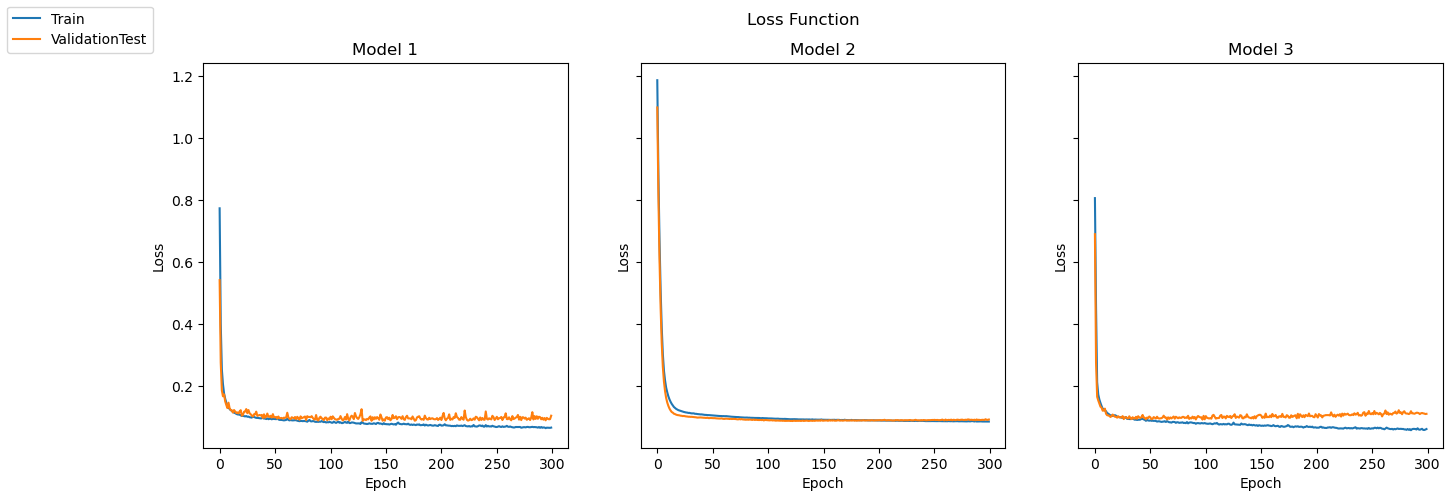

In [19]:
from matplotlib import legend
h = [h1, h2, h3]
fig, axs = plt.subplots(1,3, sharex=True, sharey=True, figsize = (16,5))
fig.suptitle('Loss Function')
for i in range(3):
  axs[i].plot(h[i].history['loss'])
  axs[i].plot(h[i].history['val_loss'])
  axs[i].set_title("Model {}".format(i + 1))

for ax in axs.flat:
    ax.set(xlabel='Epoch', ylabel='Loss')

fig.legend(labels=['Train','ValidationTest'], loc="upper left")
plt.show()

The line plot will show how the loss (how wrong the predictions are) of your model changes with each epoch during training, providing insights into how well the model is learning.
“Loss” measures how well the model is doing in terms of minimizing the error.
A good fit is when a training and validation loss decrease to a point of stability with a minimal gap between the loss values.

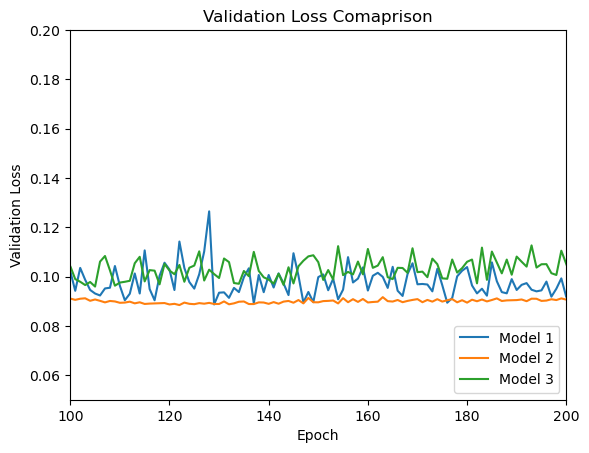

In [20]:
for i in range(3):
  plt.plot(h[i].history['val_loss'])

plt.title('Validation Loss Comaprison')
plt.ylabel('Validation Loss')
plt.xlabel('Epoch')
plt.xlim(100, 200)
plt.ylim(0.05, 0.2)
plt.legend(['Model 1', 'Model 2', 'Model 3'], loc='lower right')
plt.show()

## Evaluating the Model

### Prediction on the Test Set

In [21]:
# Model 1
y_pred_1 = CarPrice_1.predict(X_test)
# remember that these are scaled numbers; you can inverse them back:
PredictedPrice_1=scy.inverse_transform(y_pred_1)
# The actual price:
ActualPrice=scy.inverse_transform(y_test)
# Let's call the differenc between Predicted and Actual price, Error:
Error_1 = PredictedPrice_1-ActualPrice

# Model 2
y_pred_2 = CarPrice_2.predict(X_test)
PredictedPrice_2=scy.inverse_transform(y_pred_2)
Error_2 = PredictedPrice_2 - ActualPrice
# Model 3
y_pred_3 = CarPrice_3.predict(X_test)
PredictedPrice_3=scy.inverse_transform(y_pred_3)
Error_3 = PredictedPrice_3 - ActualPrice

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 


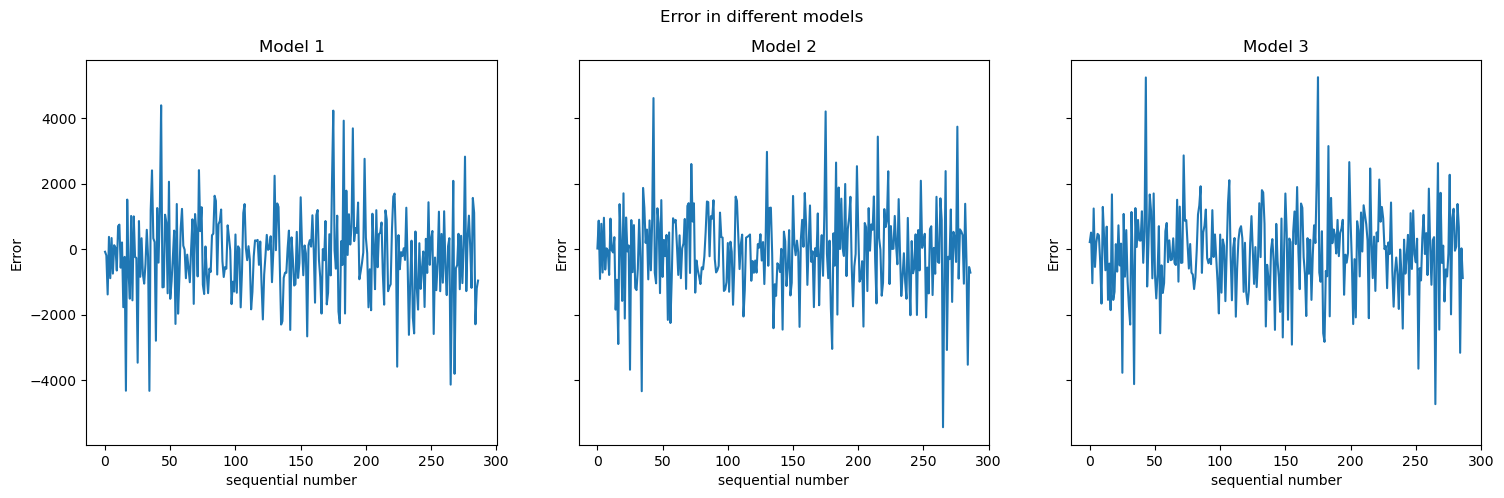

In [22]:
# Plot all 3
Error = [Error_1, Error_2, Error_3]
fig, axs = plt.subplots(1, 3, sharex=True, sharey=True, figsize = (18,5))
fig.suptitle('Error in different models')
for i in range(3):
  axs[i].plot(range(len(Error[i])), Error[i])
  axs[i].set_title('Model {}'.format(i+1))

for ax in axs.flat:
    ax.set(xlabel='sequential number', ylabel='Error')

### Checking the Model Accuracy

test accuracy of model 1: 0.85527367866206
test accuracy of model 2: 0.8720759655796934
test accuracy of model 3: 0.8529470779786128
The avergae error is $ [987.65346493 963.90473922 977.31283006]
The std in error is $ [864.4721822  846.38279785 868.8259457 ]


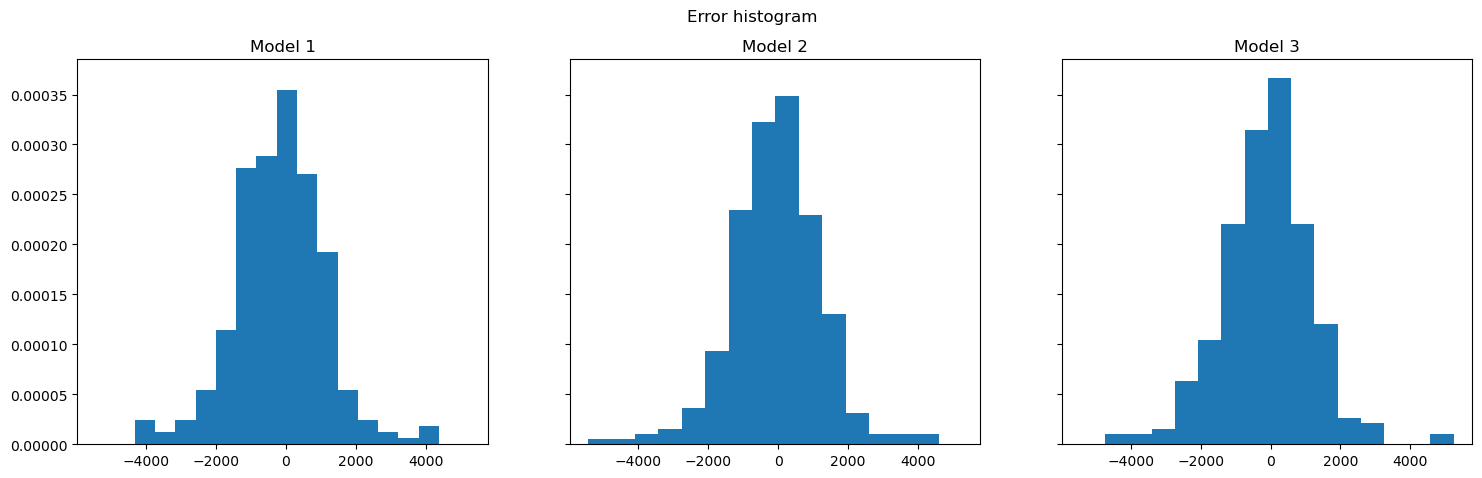

In [23]:
from sklearn.metrics import r2_score
print(f'test accuracy of model 1: {r2_score(PredictedPrice_1,ActualPrice)}')
print(f'test accuracy of model 2: {r2_score(PredictedPrice_2,ActualPrice)}')
print(f'test accuracy of model 3: {r2_score(PredictedPrice_3,ActualPrice)}')


error_mean = np.zeros(3)
error_std = np.zeros(3)

for i in range(3):
  error_mean[i] = np.average(abs(Error[i]))
  error_std[i] = np.std(np.abs(Error[i]))


#AverageError= np.average(Error_6)
#print('The avergae error is $',AverageError)
print('The avergae error is $',error_mean)
print('The std in error is $',error_std)


fig, axs = plt.subplots(1, 3, sharex=True, sharey=True, figsize = (18,5))
fig.suptitle('Error histogram')
for i in range(3):
  axs[i].hist(Error[i], 15, density=True)
  axs[i].set_title('Model {}'.format(i+1))

#n, bins, patches = plt.hist(Error_1, 15, density=True, facecolor='g', alpha=0.75)
plt.show()

# Predicting a car price

In [32]:
# Scale the input features using the feature scaler `scx`
my_car = scx.transform(np.array([[23.0, 46986, 1165.0, 90, 1, 2000.0, 3]]))

# Initialize an array to hold the predictions for each model
pred_val = np.zeros(3)

# List of models to make predictions with
models = [CarPrice_1, CarPrice_2, CarPrice_3]

# Loop over the models and make predictions
for i in range(3):
    # Make the prediction (which is still scaled), and ensure the result is in the correct shape
    predicted_scaled_price = models[i].predict(my_car)
    
    # Inverse transform the predicted price back to the original scale
    # `scy.inverse_transform` expects a 2D array, so ensure you reshape the prediction correctly
    pred_val[i] = scy.inverse_transform(predicted_scaled_price.reshape(1, -1))[0, 0]

# Print the predicted prices from each model
print(f'My car is worth $ {pred_val[0]:.2f} in Model 1, $ {pred_val[1]:.2f} in Model 2, and $ {pred_val[2]:.2f} in Model 3, respectively')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
My car is worth $ 13871.02 in Model 1, $ 15591.83 in Model 2, and $ 14617.81 in Model 3, respectively


In [36]:
# Change the Age of the car and see if the predicted price makes sense..
PredictPrice=CarPrice_1.predict(scx.transform(np.array([[3.0,46986,1165.0,90,1,2000.0,3]])))

PredictPrice=scy.inverse_transform(PredictPrice)
print(f'The car is worth $ {PredictPrice[0][0]:.2f} in Model 1')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
The car is worth $ 18640.02 in Model 1


# Regression Model

In [26]:
from sklearn.linear_model import LinearRegression
reg_model = LinearRegression()
reg_model.fit(X_train, y_train)
y_pred_reg = reg_model.predict(X_test)
from sklearn.metrics import r2_score
score = r2_score(y_test, y_pred_reg)
print('R2 Score = %.3f' %score)

R2 Score = 0.875


In [37]:
reg_pred = scy.inverse_transform(reg_model.predict(my_car))
print(f'Regression prediction of my car price is $ {reg_pred[0][0]:.2f}')

Regression prediction of my car price is $ 16265.74


# Random Forest Regressor

In [28]:
from sklearn.ensemble import RandomForestRegressor
rf=RandomForestRegressor(n_estimators=30)
rf.fit(X_train,y_train.ravel())
y_pred_rf = rf.predict(X_test)
rf_score = r2_score(y_test,y_pred_rf)
print('R2 Score = %.3f' %rf_score)

R2 Score = 0.910


In [38]:
rf_pred = scy.inverse_transform(rf.predict(my_car).reshape(-1, 1))
print(f'Regression prediction of my car price is $ {rf_pred[0][0]:.2f}')

Regression prediction of my car price is $ 13638.33


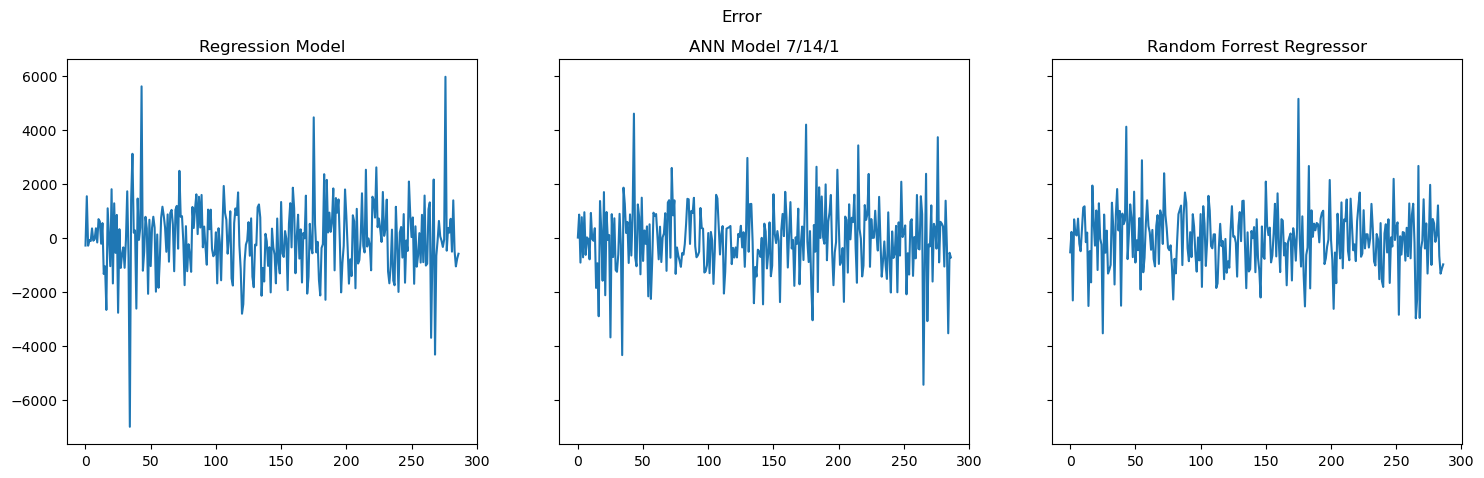

In [30]:
PredictedPrice_reg=scy.inverse_transform(y_pred_reg)
Error_reg = PredictedPrice_reg-ActualPrice
PredictedPrice_rf = scy.inverse_transform(y_pred_rf.reshape(-1, 1))
Error_rf = PredictedPrice_rf-ActualPrice

fig, axs = plt.subplots(1, 3, sharex=True, sharey=True, figsize = (18,5))
fig.suptitle('Error')
axs[0].plot(range(len(Error_reg)), Error_reg)
axs[0].set_title('Regression Model')
axs[1].plot(range(len(Error_2)), Error_2)
axs[1].set_title('ANN Model 7/14/1')
axs[2].plot(range(len(Error_rf)), Error_rf)
axs[2].set_title('Random Forrest Regressor')

plt.show()